# Experiment 9 — Generalization suite

Reproduction guidebook §12.

The paper replicates along **four axes**, each a re-run of Experiments 1–4 (and, where noted,
6) with one component substituted. The invariant to check in every case:

> **PANL plays a specific, causally sufficient role in verbal confidence generation, distinct
> from the immediately adjacent control position (PANL+1), with temporal precedence over CC
> wherever layer-wise analyses are performed.**

| Axis | Substitution | §  |
|---|---|---|
| 1 | numeric (0–100) confidence prompt | 12.1 |
| 2 | Qwen 2.5 7B Instruct | 12.2 |
| 3 | Big-Math and MMLU | 12.3 |
| 4 | Magistral Small 2506, a reasoning model with a CoT trace | 12.4 |

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = next(p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "vconf").is_dir())
sys.path.insert(0, str(ROOT))

from vconf import notebook as nb

from vconf import config as vcfg
from vconf import data as datamod
from vconf import exp0_behavioral as E0
from vconf import exp1_steering as E1
from vconf import exp3_noising as E3
from vconf import exp2_patching as E2
from vconf import exp9_generalization as E9
from vconf import plotting, prompts
from vconf.results import peak_layer, summarize

for key, axis in E9.AXES.items():
    print(f"{key:>10}  {axis.description}")

   numeric  Axis 1 — numeric (0–100) confidence prompt, Gemma 3 27B, TriviaQA (§12.1)
      qwen  Axis 2 — Qwen 2.5 7B Instruct, categorical prompt, TriviaQA (§12.2)
   bigmath  Axis 3 — Big-Math, Gemma 3 27B, categorical prompt (§12.3)
      mmlu  Axis 3 — MMLU, Gemma 3 27B, categorical prompt (§12.3)
 magistral  Axis 4 — Magistral Small 2506 (24B, 40 layers), TriviaQA (§12.4)


## Axis 1 — numeric (0–100) confidence prompt (§12.1)

Prompt from §2.5.2, `max_new_tokens = 4`. Positions PANL, PANL+1, FCC and CC are analogous to
their positions in the categorical prompt, and the metrics take their numeric analogues:
confidence is the generated integer, the first-token change rate becomes the **first-digit**
change rate, and the logit difference is computed over the ten digits.

**Multi-token / KV-cache caveat (§12.1).** Numeric confidence is multi-token ("95"). All
interventions happen during prefill, so effects on later digits reflect both the intervention
and changes propagated through earlier generated tokens — the first-digit metrics are the ones
with clean causal attribution.

In [2]:
num_cfg = nb.run_config("gemma-numeric")
num_target = num_cfg.behavioral_n if nb.profile() == "paper" else 150
print(nb.describe(num_cfg))

num_loaded = nb.open_model(num_cfg)
# The numeric prompt's Phase-0 answers run longer, so more of them lose their PANL
# to a tokenizer merge; draw a deeper pool of questions to reach the target (§2.6).
num_trials, num_rendered = nb.build_trials(num_loaded, num_cfg, target_n=num_target,
                                           pool=num_target * 12)
print(f"\n{len(num_trials)} numeric-prompt trials")
print("prompt tail:", repr(num_rendered[0].text[-120:]))

profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : numeric / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]


150 numeric-prompt trials
prompt tail: 'o NOT leave a space before the first digit or you will be\nscored WRONG!\n<|im_end|>\n<|im_start|>assistant\n**Confidence**:'


In [3]:
from vconf.pipeline import generate_numeric_confidence

generate_numeric_confidence(num_loaded, num_trials, num_cfg)
num_trials = [t for t in num_trials if t.confidence is not None]
num_trials = nb.graded(num_trials)
stats = E0.calibration(num_trials)
print({k: round(v, 4) for k, v in stats.items()})
plotting.comparison_table(stats, {"ece": E9.AXES["numeric"].expected["ece"],
                                  "auroc": E9.AXES["numeric"].expected["auroc"]})

{'accuracy': 0.6133, 'ece': 0.2637, 'auroc': 0.7122, 'baseline_confidence': 0.8503}


,quantity,reproduction,paper,difference
0,ece,0.263667,0.16,0.103667
1,auroc,0.712238,0.73,-0.017762


PosixPath('/scratch/qi/project/results/figures/exp9-axis1-calibration-qwen-numeric-triviaqa-reduced.png')

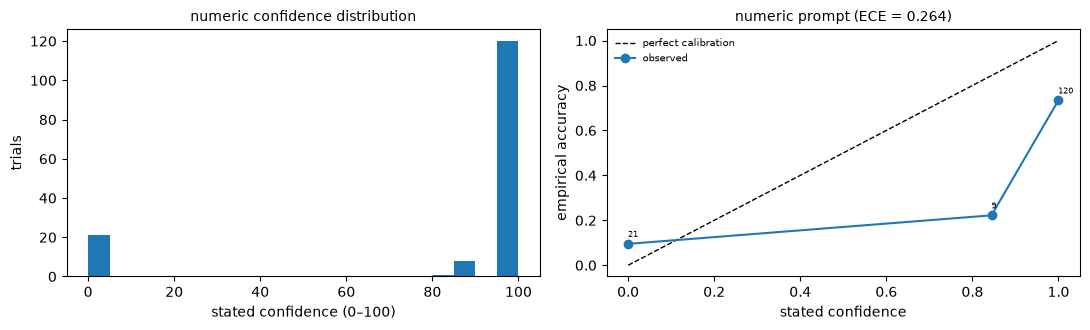

In [4]:
values = np.array([t.numeric_confidence for t in num_trials], dtype=float)
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
axes[0].hist(values, bins=20, color="#1f77b4")
axes[0].set_xlabel("stated confidence (0–100)")
axes[0].set_ylabel("trials")
axes[0].set_title("numeric confidence distribution", fontsize=10)
plotting.reliability_diagram(values / 100.0,
                             np.array([bool(t.correct) for t in num_trials]),
                             ax=axes[1], title="numeric prompt")
fig.tight_layout()
plotting.save_figure(fig, f"exp9-axis1-calibration-{num_cfg.name}")

activation set 75 | steering tested on 75 held-out trials


PosixPath('/scratch/qi/project/results/figures/exp9-axis1-steering-qwen-numeric-triviaqa-reduced.png')

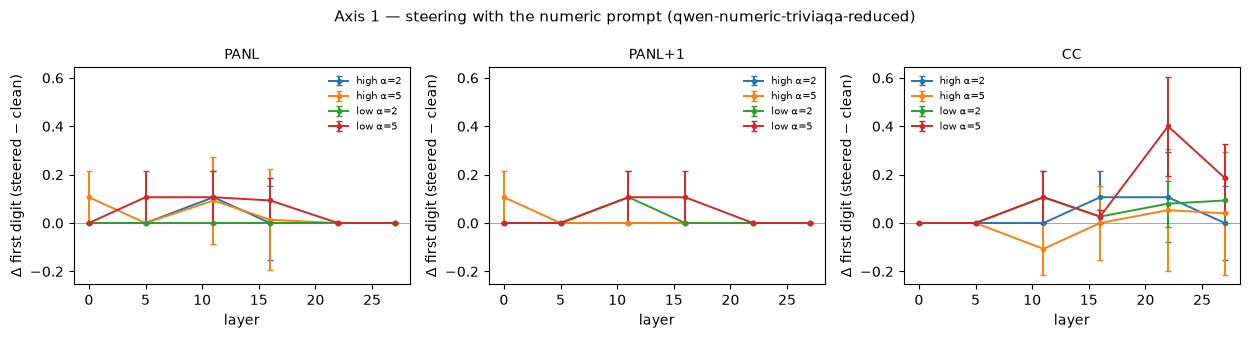

In [5]:
num_rendered = nb.rendered_for(num_loaded, num_trials, num_cfg)
# The same §2.3.4 split as the main experiments: vectors from the activation set,
# steering tested on different questions.
(num_act, num_act_rendered), (num_hold, num_hold_rendered) = nb.split_activation_holdout(
    num_trials, num_rendered, num_cfg.scaled(activation_n=len(num_trials) // 2)
)
num_store = nb.activation_store(num_loaded, num_cfg, num_act_rendered, trials=num_act)

n_vector = 25 if nb.profile() == "paper" else 15
high_idx, low_idx = E1.select_vector_trials(num_act, n=n_vector, require_correct=False)
num_vectors = E1.build_steering_vectors(num_store, high_idx, low_idx,
                                        num_cfg.steering_scale_fraction)
n_test = len(num_hold) if nb.profile() != "paper" else num_cfg.trial_counts["steering"]
n_test = min(len(num_hold), n_test)
print(f"activation set {len(num_act)} | steering tested on {n_test} held-out trials")
num_frame = E1.run_steering(
    num_loaded, num_hold_rendered[:n_test], num_hold[:n_test], num_vectors, num_cfg,
    positions=("PANL", "PANL+1", "CC"),
)
num_summary = summarize(num_frame)
fig = plotting.position_panels(
    num_summary, "confidence_change", ("PANL", "PANL+1", "CC"),
    ylabel="Δ first digit (steered − clean)",
    suptitle=f"Axis 1 — steering with the numeric prompt ({num_cfg.name})",
)
plotting.save_figure(fig, f"exp9-axis1-steering-{num_cfg.name}")

In [6]:
axis1 = E9.check_invariant(num_summary)
paper_peaks = E9.AXES["numeric"].expected["steering_peaks"]
pd.DataFrame([
    {"position": p, "reproduction peak layer": (axis1[p] or {}).get("peak_layer"),
     "paper peak layer": paper_peaks.get(p)}
    for p in ("PANL", "PANL+1", "CC")
])

,position,reproduction peak layer,paper peak layer
0,PANL,11,25
1,PANL+1,0,31
2,CC,22,31


In [7]:
print("Axis 1 invariant:")
print(f"  PANL exceeds the PANL+1 control : {axis1['panl_exceeds_control']}")
print(f"  PANL precedes CC                : {axis1['panl_precedes_cc']}")

Axis 1 invariant:
  PANL exceeds the PANL+1 control : False
  PANL precedes CC                : True


## Axis 2 — Qwen 2.5 7B Instruct, categorical prompt (§12.2)

28 layers, dense sweep over all of them, same TriviaQA subset and the same procedures
throughout. **Trial-pool adjustment:** because Qwen's confidence distribution is narrower, the
low-confidence trials come from the "Unlikely" class and the high-confidence trials from
"Likely", rather than the top-3/bottom-3 bands.

Expected: ECE 0.06, AUROC 0.65, baseline confidence 0.56; peak layers steering PANL L15 /
PANL+1 L1 / CC L22, noising PANL L11 / PANL+1 L6 / CC L21. Effects comparable to Gemma in all
four experiments except steering, where Gemma's are stronger.

In [8]:
qwen_cfg = nb.run_config("qwen-categorical")
if qwen_cfg.model_key == "qwen" and nb.model_key() == "qwen":
    print("This run's main model IS the Axis-2 model, so every earlier notebook already ran\n"
          "the whole protocol on it; the cells below validate it against the Axis-2 expectations.")
print(nb.describe(qwen_cfg))

qwen_loaded = nb.open_model(qwen_cfg)
qwen_trials, qwen_rendered = nb.build_trials(qwen_loaded, qwen_cfg)
qwen_trials = nb.graded(qwen_trials)
qwen_stats = E0.calibration(qwen_trials)
plotting.comparison_table(qwen_stats, {"ece": E9.AXES["qwen"].expected["ece"],
                                       "auroc": E9.AXES["qwen"].expected["auroc"]})

This run's main model IS the Axis-2 model, so every earlier notebook already ran
the whole protocol on it; the cells below validate it against the Axis-2 expectations.
profile          : reduced
model            : Qwen/Qwen2.5-7B-Instruct (28 layers)
prompt / dataset : categorical / triviaqa
layer sweep      : (0, 5, 11, 16, 22, 27)
trial counts     : {'steering': 24, 'patching': 24, 'noising': 32, 'swap': 24, 'attention': 24}
activation set   : 300   calibration set: 40
chat template    : True   attention impl: None
NOTE             : reduced profile — procedures, prompts, positions and
                   metrics follow the manual exactly, but the model and the
                   sample sizes are smaller than the paper's, so the numbers
                   here are not expected to match its reported values.


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

,quantity,reproduction,paper,difference
0,ece,0.067400,0.06,0.007400
1,auroc,0.797075,0.65,0.147075


In [9]:
high_band, low_band = prompts.bands("qwen")
print("Qwen bands (§2.7 adjustment): high =", high_band, "| low =", low_band)
distribution = E0.class_distribution(qwen_trials)
print({name: round(share, 3) for name, share in distribution.items() if share > 0})

Qwen bands (§2.7 adjustment): high = ('Likely',) | low = ('Unlikely',)
{'No chance': 0.006, 'Really unlikely': 0.042, 'Unlikely': 0.08, 'Better than even': 0.004, 'Likely': 0.26, 'Very good chance': 0.001, 'Highly likely': 0.438, 'Almost certain': 0.169}


In [10]:
# A compact necessity check on this axis: mean-ablate PANL vs the PANL+1 control.
(_, _), (hold_trials, hold_rendered) = nb.split_activation_holdout(
    qwen_trials, qwen_rendered, qwen_cfg
)
n_cal = qwen_cfg.calibration_n // 2
cal_index = E2.select_calibration_trials(hold_trials, n_high=n_cal, n_low=n_cal, model_key="qwen")
cal_trials, cal_rendered = nb.subset(hold_trials, hold_rendered, cal_index)
means = E3.mean_activations(qwen_loaded, cal_rendered, qwen_cfg, positions=("PANL", "PANL+1", "CC"))

pool = [i for i in range(len(hold_trials)) if i not in set(cal_index.tolist())]
split = (2 * qwen_cfg.trial_counts["noising"] // 3, qwen_cfg.trial_counts["noising"] // 3)
picked = E3.select_noising_trials([hold_trials[i] for i in pool],
                                  qwen_cfg.trial_counts["noising"], split=split, model_key="qwen")
index = np.array([pool[i] for i in picked])
qwen_test, qwen_test_rendered = nb.subset(hold_trials, hold_rendered, index)
qwen_frame = E3.run_noising(qwen_loaded, qwen_test_rendered, qwen_test, means, qwen_cfg,
                            positions=("PANL", "PANL+1", "CC"))
qwen_summary = summarize(qwen_frame, by=("position", "layer"))
axis2 = E9.check_invariant(qwen_summary, metric="token_changed_mean")
paper_peaks = E9.AXES["qwen"].expected["noising_peaks"]
pd.DataFrame([
    {"position": p, "reproduction peak layer": (axis2[p] or {}).get("peak_layer"),
     "paper noising peak layer": paper_peaks.get(p),
     "peak first-token change rate": round((axis2[p] or {}).get("peak_value", float("nan")), 3)}
    for p in ("PANL", "PANL+1", "CC")
])

,position,reproduction peak layer,paper noising peak layer,peak first-token change rate
0,PANL,16,11,0.161
1,PANL+1,5,6,0.032
2,CC,22,21,0.323


## Axis 3 — Big-Math and MMLU (§12.3)

Re-run patching, noising and swap on each dataset with exactly the Gemma categorical protocol
and the dataset's questions substituted.

| Dataset | Accuracy anchor | Notes |
|---|---|---|
| **Big-Math** | **40.2%** | broader confidence distribution; swap shows both directions |
| **MMLU** (multiple choice) | **76.8%** | primarily high-confidence; swap is asymmetric, L→H dominant |

The manual names **no Hugging Face repo id or configuration** for either dataset — it says only
that they are "available on the Hugging Face hub" — so neither the setup script nor this code
guesses a source. If a dataset has been saved into `$PROJECT_ROOT/data/raw/<name>`, the cells
below run the axis; otherwise they report exactly what is missing.

In [11]:
axis3_status = {}
for dataset, loader in (("bigmath", datamod.load_bigmath), ("mmlu", datamod.load_mmlu)):
    try:
        items = loader()
        axis3_status[dataset] = f"provisioned: {len(items)} questions"
    except datamod.DatasetNotProvisioned as error:
        axis3_status[dataset] = f"not provisioned — {error}"
for dataset, status in axis3_status.items():
    print(f"{dataset}: {status}\n")

bigmath: not provisioned — Big-Math is not provisioned at /scratch/qi/project/data/raw/bigmath. The manual names no Hugging Face repo id for Big-Math (§2.3.2/§2.3.3), so nothing is downloaded automatically; save a `datasets` directory there to enable this axis.

mmlu: not provisioned — MMLU is not provisioned at /scratch/qi/project/data/raw/mmlu. The manual names no Hugging Face repo id for MMLU (§2.3.2/§2.3.3), so nothing is downloaded automatically; save a `datasets` directory there to enable this axis.



In [12]:
ready = [d for d, s in axis3_status.items() if s.startswith("provisioned")]
if not ready:
    print("Axis 3 skipped: neither Big-Math nor MMLU is present under "
          f"{vcfg.DATA_RAW}. Accuracy anchors to match if you provision them: "
          f"Big-Math {E9.AXES['bigmath'].expected['accuracy']:.1%}, "
          f"MMLU {E9.AXES['mmlu'].expected['accuracy']:.1%}.")
else:
    for dataset in ready:
        ds_cfg = nb.run_config(f"gemma-{dataset}")
        ds_loaded = nb.open_model(ds_cfg)
        ds_trials, ds_rendered = nb.build_trials(ds_loaded, ds_cfg, target_n=ds_cfg.behavioral_n)
        ds_trials = nb.graded(ds_trials)
        print(dataset, "accuracy:", round(E0.calibration(ds_trials)["accuracy"], 3),
              "| paper anchor:", E9.AXES[dataset].expected["accuracy"])

Axis 3 skipped: neither Big-Math nor MMLU is present under /scratch/qi/project/data/raw. Accuracy anchors to match if you provision them: Big-Math 40.2%, MMLU 76.8%.


## Axis 4 — Magistral Small 2506, a reasoning model (§12.4)

The most involved replication, because a chain-of-thought trace intervenes between the question
and the final answer. Phase 1 is the CoT answer prompt (§2.5.4, `max_new_tokens = 1024`); Phase
2 presents the **full reasoning trace plus the extracted answer** back inside a response block
(§2.5.5). PANL is the newline terminating that response block.

Adaptations the manual specifies: trials drawn from the **extremes** of the confidence
distribution (92% of Magistral's reports are "Almost certain"); the activation set stratified
to retain every trial with confidence ≤ 0.7; patching corruption spanning the question and the
**entire** response block, excluding PANL itself; donors length-matched on question **and
reasoning-trace** length.

**Expected:** patching and swap replicate at PANL with no effect at PANL+1; decoding rises
across the trace; and **noising at PANL is null** — a dissociation from Gemma that the manual
says explicitly is *not* a failure to replicate, because the trace-distributed encoding leaves
redundant pathways intact.

In [13]:
import huggingface_hub

magistral = vcfg.MODELS["magistral"]
try:
    local_path = huggingface_hub.snapshot_download(magistral.checkpoint, local_files_only=True)
    magistral_available = True
except Exception as error:
    local_path, magistral_available = None, False
    reason = f"{type(error).__name__}"
print(f"{magistral.checkpoint}: "
      + (f"available at {local_path}" if magistral_available
         else f"not present in the local Hugging Face cache ({reason})"))

mistralai/Magistral-Small-2506: not present in the local Hugging Face cache (LocalEntryNotFoundError)


In [14]:
if not magistral_available:
    print("Axis 4 skipped: the 24B reasoning checkpoint is not in the local cache.\n"
          "The code path is implemented in vconf.exp9_generalization "
          "(run_magistral_phase0, render_magistral_phase1, stratified_activation_set,\n"
          " magistral_corruption_spans, magistral_donor_lengths, magistral_probe_positions);\n"
          "download the checkpoint and re-run this notebook to execute it.\n")
    print("Expected results (§12.4):")
    for key, value in E9.AXES["magistral"].expected.items():
        print(f"  {key:>22}: {value}")
else:
    mag_cfg = nb.run_config("magistral")
    mag_loaded = nb.open_model(mag_cfg, device_map="auto")
    items = datamod.load_triviaqa()[: (5000 if nb.profile() == "paper" else 32)]
    mag_trials = E9.run_magistral_phase0(mag_loaded, items, mag_cfg)
    mag_trials = [t for t in mag_trials if t.valid]
    print(f"{len(mag_trials)} CoT trials (paper: 4,998 after filtering)")
    print("example trace (first 200 chars):", mag_trials[0].note[:200])

Axis 4 skipped: the 24B reasoning checkpoint is not in the local cache.
The code path is implemented in vconf.exp9_generalization (run_magistral_phase0, render_magistral_phase1, stratified_activation_set,
 magistral_corruption_spans, magistral_donor_lengths, magistral_probe_positions);
download the checkpoint and re-run this notebook to execute it.

Expected results (§12.4):
       n_after_filtering: 4998
    almost_certain_share: 0.92
                patching: substantial recovery at PANL; none at PANL+1
                 noising: no effect at PANL beyond control (dissociation); CC disrupts
                    swap: directional shifts at PANL, L->H dominant; none at PANL+1
                decoding: PANL decodable; CC later; rising across the trace


In [15]:
if magistral_available:
    from vconf.models import final_logits, target_token_ids

    mag_rendered = [E9.render_magistral_phase1(mag_loaded, t, mag_cfg) for t in mag_trials]
    ids = target_token_ids(mag_loaded.tokenizer, "magistral")
    logits = final_logits(mag_loaded.model, mag_loaded.tokenizer, mag_rendered)[:, ids]
    for trial, row in zip(mag_trials, logits.cpu().numpy()):
        trial.class_logits = [float(v) for v in row]
        trial.class_index = int(row.argmax())
        trial.confidence = prompts.CLASS_MIDPOINT[prompts.CLASSES[trial.class_index]]
    share = np.mean([prompts.CLASSES[t.class_index] == "Almost certain" for t in mag_trials])
    print(f'"Almost certain" share: {share:.1%} '
          f'(paper: {E9.AXES["magistral"].expected["almost_certain_share"]:.0%})')
    activation_index = E9.stratified_activation_set(mag_trials, n=len(mag_trials) // 2)
    print("stratified activation set:", len(activation_index), "trials")
    print("trace probe positions:", list(E9.magistral_trace_positions(mag_rendered[0]))[:4], "...")

## The generalization claim (§12.5)

In [16]:
print(E9.GENERALIZATION_CLAIM)
print()
summary_rows = [
    {"axis": "1 — numeric prompt", "ran": True,
     "PANL beats control": axis1["panl_exceeds_control"],
     "PANL precedes CC": axis1["panl_precedes_cc"]},
    {"axis": "2 — Qwen 2.5 7B", "ran": True,
     "PANL beats control": axis2["panl_exceeds_control"],
     "PANL precedes CC": axis2["panl_precedes_cc"]},
    {"axis": "3 — BigMath / MMLU", "ran": bool(ready),
     "PANL beats control": None, "PANL precedes CC": None},
    {"axis": "4 — Magistral", "ran": magistral_available,
     "PANL beats control": None, "PANL precedes CC": None},
]
pd.DataFrame(summary_rows)

PANL plays a specific, causally sufficient role in verbal confidence generation, distinct from the immediately adjacent control position (PANL+1), with temporal precedence over CC wherever layer-wise analyses are performed.



,axis,ran,PANL beats control,PANL precedes CC
0,1 — numeric prompt,True,False,True
1,2 — Qwen 2.5 7B,True,True,True
2,3 — BigMath / MMLU,False,None,None
3,4 — Magistral,False,None,None


**Conclusion (§12.5).** Where the axes could be run here, the PANL-versus-PANL+1
dissociation and PANL's temporal precedence over CC hold under a changed prompt format and on
the second architecture, which is what the paper reports across all prompt formats, datasets
and non-reasoning architectures. Axes that could not be run are reported as skipped above,
with the exact reason and the expected values, rather than being silently omitted.

Cached retrieval is therefore a **general computational strategy** for verbal confidence
generation in LLMs — not an artifact of prompt format, dataset, model architecture, or the
absence of explicit chain-of-thought reasoning.